In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, GlobalAveragePooling2D
import random

In [2]:
# generators

train_ds = keras.utils.image_dataset_from_directory(
    directory = r'C:\Users\mabin\Desktop\DataScienceClassNotes\DogVsCat_Classification_Project\train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size =(128, 128)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = r'C:\Users\mabin\Desktop\DataScienceClassNotes\DogVsCat_Classification_Project\validation',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size =(128, 128)
)

test_ds = keras.utils.image_dataset_from_directory(
    directory = r'C:\Users\mabin\Desktop\DataScienceClassNotes\DogVsCat_Classification_Project\test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size =(128, 128)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 12461 files belonging to 2 classes.


In [3]:
# Normalize

def process(image,label):
    image = tf.cast(image/255. , tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

There are two ways to create model

## Method - 1

In [4]:
# create CNN model

model = Sequential()

model.add(Conv2D(16, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='same'))

model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='same'))

model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='same'))

# Here i am using GlobalAveragePooling2D for fast processing
# we can use Flatten() but GlobalAveragePooling2D is more fast
model.add(GlobalAveragePooling2D())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Method - 2

In [5]:
"""
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),
    
    Conv2D(32, (3,3), activation='relu',),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),
    
    Conv2D(64, (3,3), activation='relu',),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),
    
    Flatten(),
    
    Dense(64, activation='relu'),
    model.add(Dropout(0.1)),
    Dense(32, activation='relu'),
    model.add(Dropout(0.1)),
    Dense(1, activation='sigmoid')
])

"""

"\nmodel = Sequential([\n    Conv2D(16, (3,3), activation='relu', input_shape=(128, 128, 3)),\n    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),\n\n    Conv2D(32, (3,3), activation='relu',),\n    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),\n\n    Conv2D(64, (3,3), activation='relu',),\n    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),\n\n    Flatten(),\n\n    Dense(64, activation='relu'),\n    model.add(Dropout(0.1)),\n    Dense(32, activation='relu'),\n    model.add(Dropout(0.1)),\n    Dense(1, activation='sigmoid')\n])\n\n"

In [6]:
# This helps us to check wether the model is working or not
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
history = model.fit(train_ds, epochs=6, validation_data=validation_ds)

Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.5569 - loss: 0.6763 - val_accuracy: 0.6030 - val_loss: 0.6538
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 58ms/step - accuracy: 0.6345 - loss: 0.6350 - val_accuracy: 0.6422 - val_loss: 0.6366
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - accuracy: 0.6884 - loss: 0.5892 - val_accuracy: 0.6964 - val_loss: 0.5830
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7111 - loss: 0.5593 - val_accuracy: 0.7064 - val_loss: 0.5635
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.7308 - loss: 0.5362 - val_accuracy: 0.6964 - val_loss: 0.5761
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.7446 - loss: 0.5174 - val_accuracy: 0.7420 - val_loss: 0.5325


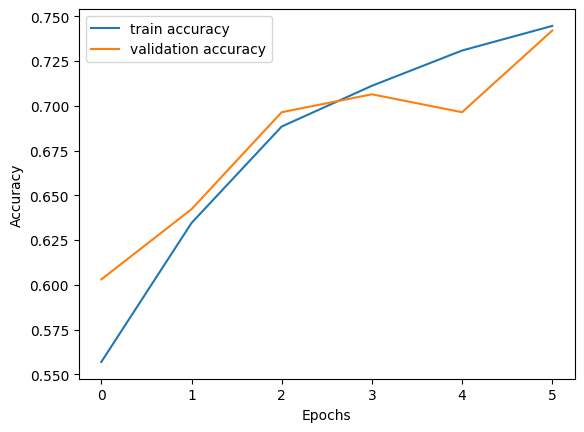

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [10]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

390/390 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6536 - loss: 38.4609
Test accuracy: 0.6536393761634827


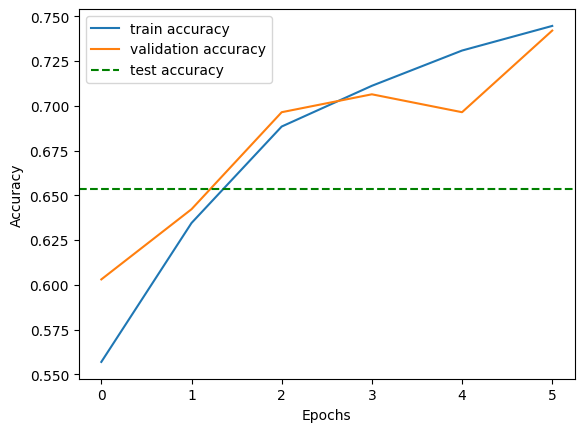

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.axhline(y=test_acc, color='green', linestyle='--', label='test accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


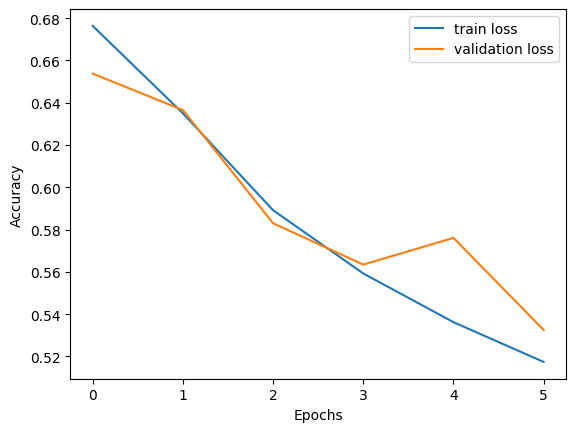

In [49]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

# plt.axhline(y=test_acc, color='green', linestyle='--', label='test accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [91]:
import numpy as np

idx = random.randint(0, len(test_ds))

class_names = test_ds.class_names

image, label = next(iter(test_ds))


img = image[0]     # shape: (H, W, C)
true_label = label[0]

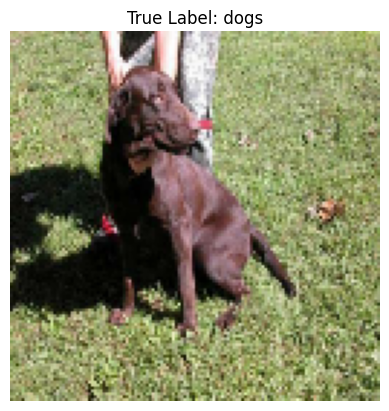

In [92]:
plt.imshow(img.numpy().astype("uint8"))
plt.title(f"True Label: {class_names[true_label.numpy()]}")
plt.axis("off")
plt.show()

In [93]:
img.shape

TensorShape([128, 128, 3])

In [94]:
img_array = tf.expand_dims(img, axis=0)


In [95]:
prediction = model.predict(img_array)[0][0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [96]:
if prediction > 0.5:
    pred_label = "dog"
else:
    pred_label = "cat"

print("Predicted:", pred_label)
print("Actual:", class_names[true_label.numpy()])
print("Confidence:", prediction if prediction > 0.5 else 1 - prediction)

Predicted: dog
Actual: dogs
Confidence: 1.0
